# Okun's Law: GDP Growth and Unemployment — Cross-Country Analysis

**ACC102 Mini Assignment | Track 4 | Xi'an Jiaotong-Liverpool University**  
**Semester 2, 2025-2026**

---

## 1. Problem Definition

**Research question:** Does Okun's Law hold across different economies, and do the estimated Okun coefficients differ significantly between developed and developing countries?

**Okun's Law** (Okun, 1962) is an empirical relationship stating that when an economy grows faster than its potential rate, unemployment tends to fall. The **difference version** used here is:

$$\Delta U_t = \alpha + \beta \cdot g_t + \varepsilon_t$$

Where:
- $\Delta U_t$ = change in unemployment rate (percentage points)
- $g_t$ = GDP growth rate (%)
- $\beta$ = **Okun coefficient** (expected to be negative)

**Target audience:** Economics students and policy researchers who want to compare macroeconomic dynamics across countries without manually processing raw data.

This notebook covers the full analytical workflow underpinning the Streamlit interactive tool.

## 2. Setup and Data Acquisition

**Data source:** World Bank Open Data  
**Indicators:**
- `NY.GDP.MKTP.KD.ZG` — GDP growth (annual %)  
- `SL.UEM.TOTL.ZS` — Unemployment rate (% of total labour force)  

**Countries:** China, United States, United Kingdom, Germany, Japan, France, India, Brazil  
**Period:** 1991–2023  
**Access date:** April 2026

In [1]:
# Install required libraries if needed
# !pip install pandas pandas-datareader numpy matplotlib scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
import pandas_datareader.wb as wb

countries = ['CN', 'US', 'GB', 'JP', 'DE', 'FR', 'IN', 'BR']
START_YEAR = 1991
END_YEAR   = 2023

# Fetch GDP growth (annual %)
gdp = wb.download(
    indicator='NY.GDP.MKTP.KD.ZG',
    country=countries,
    start=START_YEAR, end=END_YEAR
).rename(columns={'NY.GDP.MKTP.KD.ZG': 'GDP_growth'})

# Fetch unemployment rate (%)
unem = wb.download(
    indicator='SL.UEM.TOTL.ZS',
    country=countries,
    start=START_YEAR, end=END_YEAR
).rename(columns={'SL.UEM.TOTL.ZS': 'Unemployment'})

print('Data fetched.')
print('GDP shape:', gdp.shape, '| Unemployment shape:', unem.shape)

Data fetched.
GDP shape: (264, 1) | Unemployment shape: (264, 1)


## 3. Data Cleaning and Transformation

In [4]:
# Join datasets
df = gdp.join(unem).reset_index()
df['year'] = df['year'].astype(int)

print('Missing values before cleaning:')
print(df.isnull().sum())

df = df.dropna()
print(f'\nRows after dropping NaN: {len(df)}')

Missing values before cleaning:
country         0
year            0
GDP_growth      0
Unemployment    0
dtype: int64

Rows after dropping NaN: 264


In [5]:
# Compute year-over-year change in unemployment (Delta_U)
# This is the dependent variable in Okun's difference specification
df = df.sort_values(['country', 'year'])
df['Delta_U'] = df.groupby('country')['Unemployment'].diff()

# Drop first year per country (no lag available)
df = df.dropna(subset=['Delta_U'])

print('Final dataset shape:', df.shape)
df.head(10)

Final dataset shape: (256, 5)


,country,year,GDP_growth,Unemployment,Delta_U
31,Brazil,1992,-0.544072,7.086,0.199
30,Brazil,1993,4.924690,6.030,-1.056
29,Brazil,1994,5.852870,6.579,0.549
28,Brazil,1995,4.223794,7.092,0.513
27,Brazil,1996,2.208864,8.035,0.943
26,Brazil,1997,3.394846,9.003,0.968
25,Brazil,1998,0.338098,10.150,1.147
24,Brazil,1999,0.467938,11.125,0.975
23,Brazil,2000,4.387949,10.889,-0.236
22,Brazil,2001,1.389896,10.649,-0.240


In [6]:
# Descriptive statistics
print('=== Descriptive Statistics ===')
df.groupby('country')[['GDP_growth', 'Unemployment', 'Delta_U']].describe().round(2)

=== Descriptive Statistics ===


GDP_growth                                               \
                    count  mean   std    min   25%   50%    75%    max   
country                                                                  
Brazil               32.0  2.41  2.72  -3.55  0.98  3.01   4.26   7.53   
China                32.0  8.97  2.86   2.34  7.34  8.91  10.25  14.30   
France               32.0  1.56  2.28  -7.44  0.99  1.89   2.53   6.88   
Germany              32.0  1.27  2.08  -5.54  0.78  1.65   2.32   4.13   
India                32.0  6.28  2.82  -5.78  5.14  7.10   7.92   9.69   
Japan                32.0  0.76  1.94  -5.69  0.04  1.03   1.71   4.10   
United Kingdom       32.0  2.13  3.05 -10.05  1.55  2.36   3.23   8.54   
United States        32.0  2.59  1.75  -2.58  2.09  2.72   3.59   6.06   

               Unemployment        ...               Delta_U              \
                      count  mean  ...    75%    max   count  mean   std   
country                            ...                                     
Brazil                 32.0  9.50  ...  10.95  13.70    32.0  0.03  1.24   
China                  32.0  4.11  ...   4.58   5.00    32.0  0.07  0.22   
France                 32.0  9.63  ...  10.29  12.59    32.0 -0.06  0.75   
Germany                32.0  6.87  ...   8.75  11.19    32.0 -0.07  0.79   
India                  32.0  7.35  ...   7.64   7.86    32.0 -0.11  0.50   
Japan                  32.0  3.74  ...   4.58   5.39    32.0  0.02  0.38   
United Kingdom         32.0  6.20  ...   7.81  10.35    32.0 -0.14  0.73   
United States          32.0  5.74  ...   6.35   9.63    32.0 -0.10  1.29   

                                              
                 min   25%   50%   75%   max  
country                                       
Brazil         -3.93 -0.61 -0.21  0.95  3.04  
China          -0.45 -0.08  0.02  0.22  0.54  
France         -1.76 -0.51 -0.05  0.24  1.74  
Germany        -1.54 -0.58 -0.25  0.68  1.35  
India          -1.56 -0.03 -0.00  0.02  1.35  
Japan          -0.55 -0.26 -0.01  0.26  1.07  
United Kingdom -1.35 -0.66 -0.22  0.30  1.93  
United States  -2.71 -0.62 -0.45  0.05  4.39  

[8 rows x 24 columns]

## 4. Exploratory Visualisation — Trend Charts

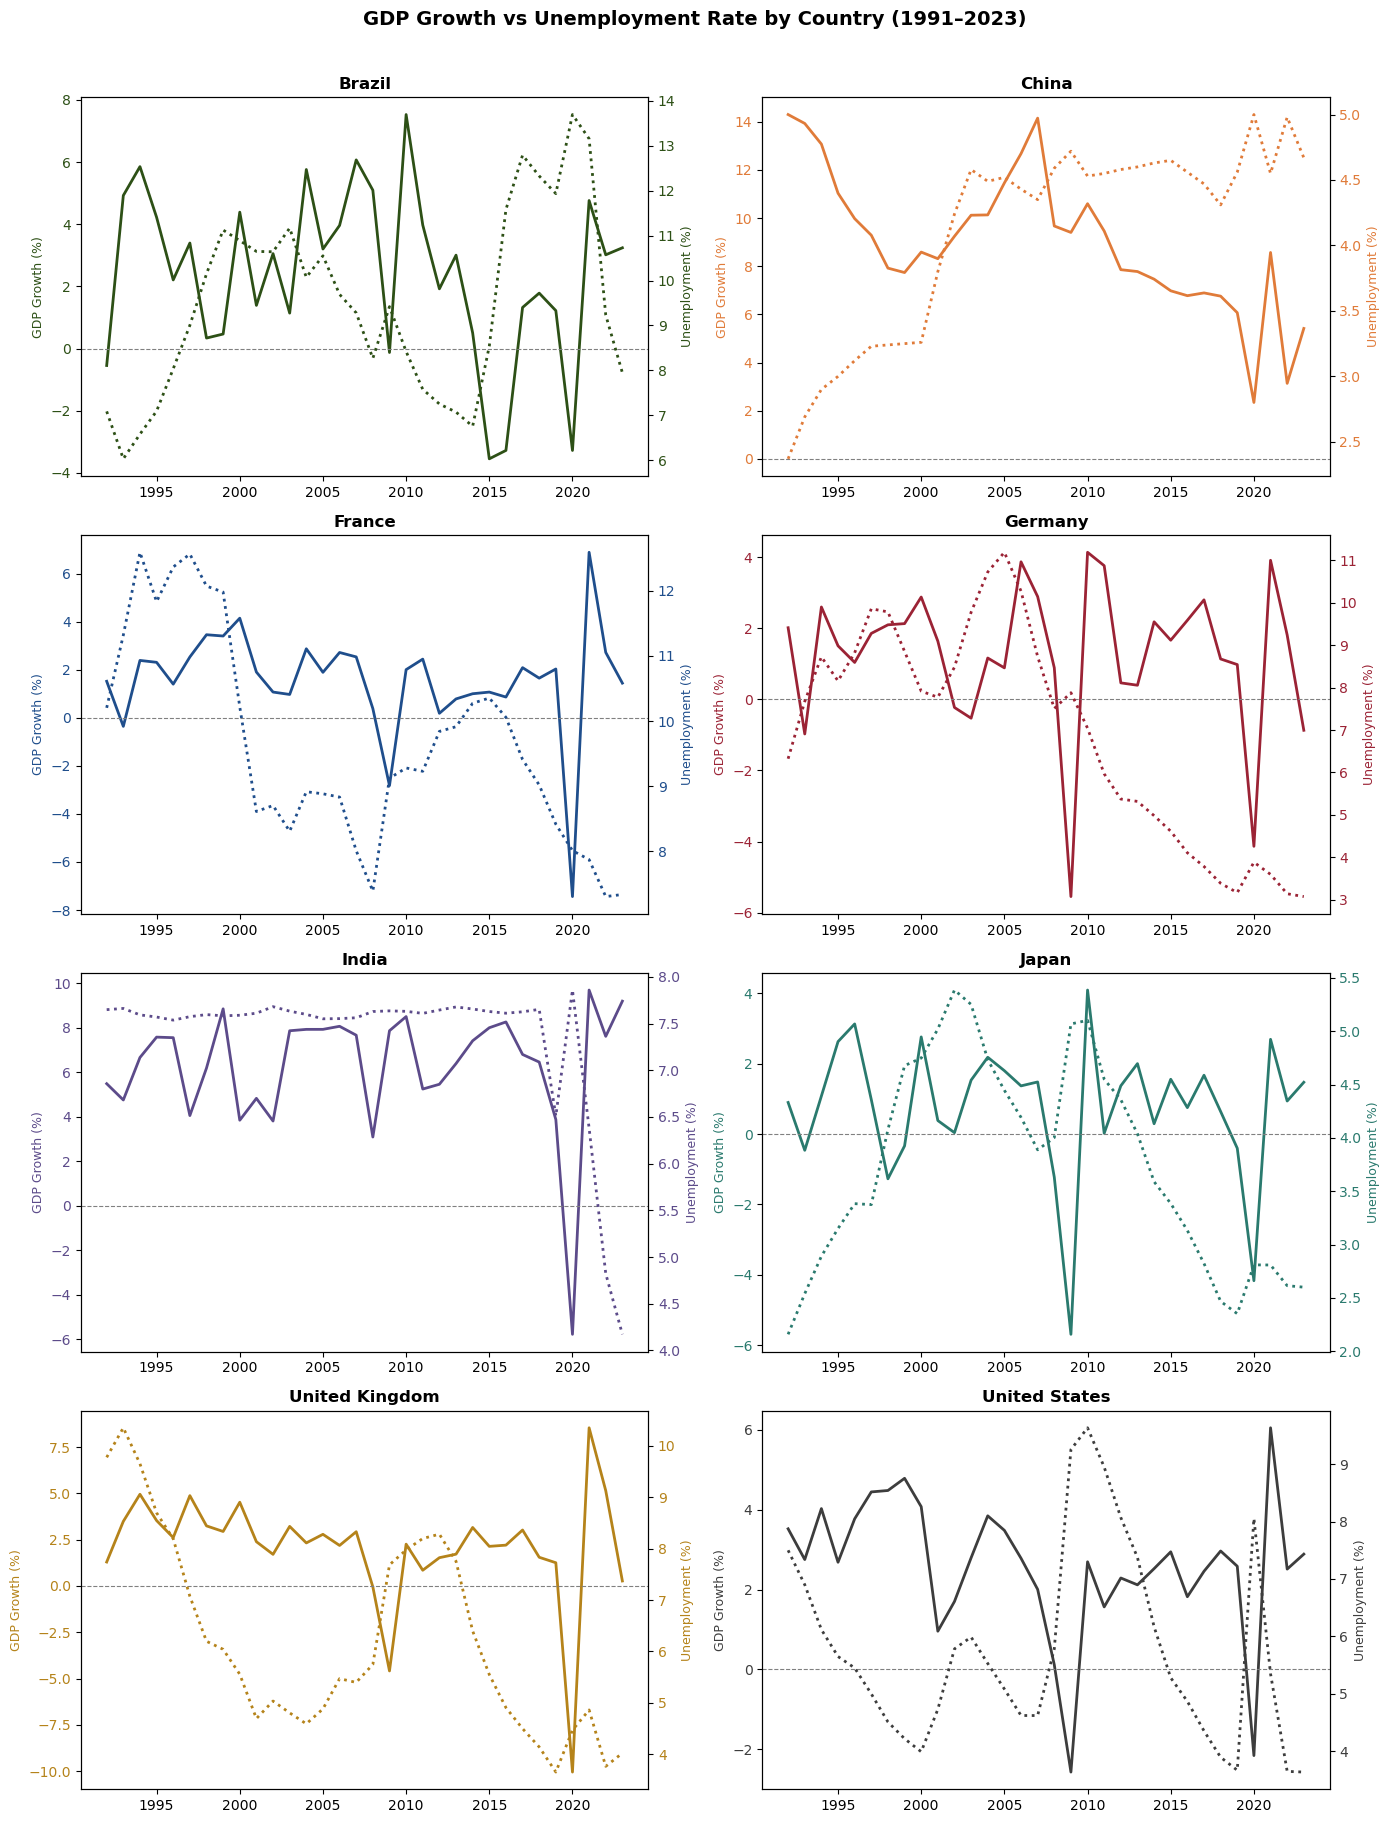

Saved: trend_charts.png


In [7]:
COUNTRIES_PLOT = df['country'].unique()
COLORS = ['#2d5016','#e07b39','#1f4e8c','#9b2335','#5c4b8a','#2a7a6e','#b5831a','#3d3d3d']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, (country, col) in enumerate(zip(COUNTRIES_PLOT, COLORS)):
    cdf = df[df['country'] == country]
    ax1 = axes[i]
    ax2 = ax1.twinx()

    ax1.plot(cdf['year'], cdf['GDP_growth'], color=col, linewidth=2, label='GDP Growth (%)')
    ax1.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax2.plot(cdf['year'], cdf['Unemployment'], color=col, linewidth=2,
             linestyle='dotted', label='Unemployment (%)')

    ax1.set_title(country, fontsize=12, fontweight='bold')
    ax1.set_ylabel('GDP Growth (%)', color=col, fontsize=9)
    ax2.set_ylabel('Unemployment (%)', color=col, fontsize=9)
    ax1.tick_params(axis='y', labelcolor=col)
    ax2.tick_params(axis='y', labelcolor=col)

plt.suptitle('GDP Growth vs Unemployment Rate by Country (1991–2023)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('trend_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: trend_charts.png')

## 5. Okun's Law — OLS Regression

In [8]:
results = []

for country in COUNTRIES_PLOT:
    cdf = df[df['country'] == country].dropna(subset=['GDP_growth', 'Delta_U'])
    if len(cdf) < 5:
        continue
    slope, intercept, r_value, p_value, std_err = linregress(cdf['GDP_growth'], cdf['Delta_U'])
    results.append({
        'Country': country,
        'Okun Coefficient (β)': round(slope, 4),
        'Intercept (α)': round(intercept, 4),
        'R²': round(r_value**2, 4),
        'p-value': round(p_value, 4),
        'Significant (p<0.05)': p_value < 0.05,
        'n': len(cdf)
    })

results_df = pd.DataFrame(results).set_index('Country')
print('=== Okun Coefficient Estimates ===')
results_df

=== Okun Coefficient Estimates ===


,Okun Coefficient (β),Intercept (α),R²,p-value,Significant (p<0.05),n
Country,,,,,,
Brazil,-0.2849,0.7186,0.3931,0.0001,True,32
China,-0.0086,0.1493,0.0123,0.5456,False,32
France,-0.0863,0.0785,0.0686,0.1476,False,32
Germany,-0.1798,0.1580,0.2242,0.0062,True,32
India,-0.0955,0.4912,0.2868,0.0016,True,32
Japan,-0.1083,0.0991,0.3122,0.0009,True,32
United Kingdom,-0.1247,0.1237,0.2734,0.0021,True,32
United States,-0.5962,1.4462,0.6466,0.0000,True,32


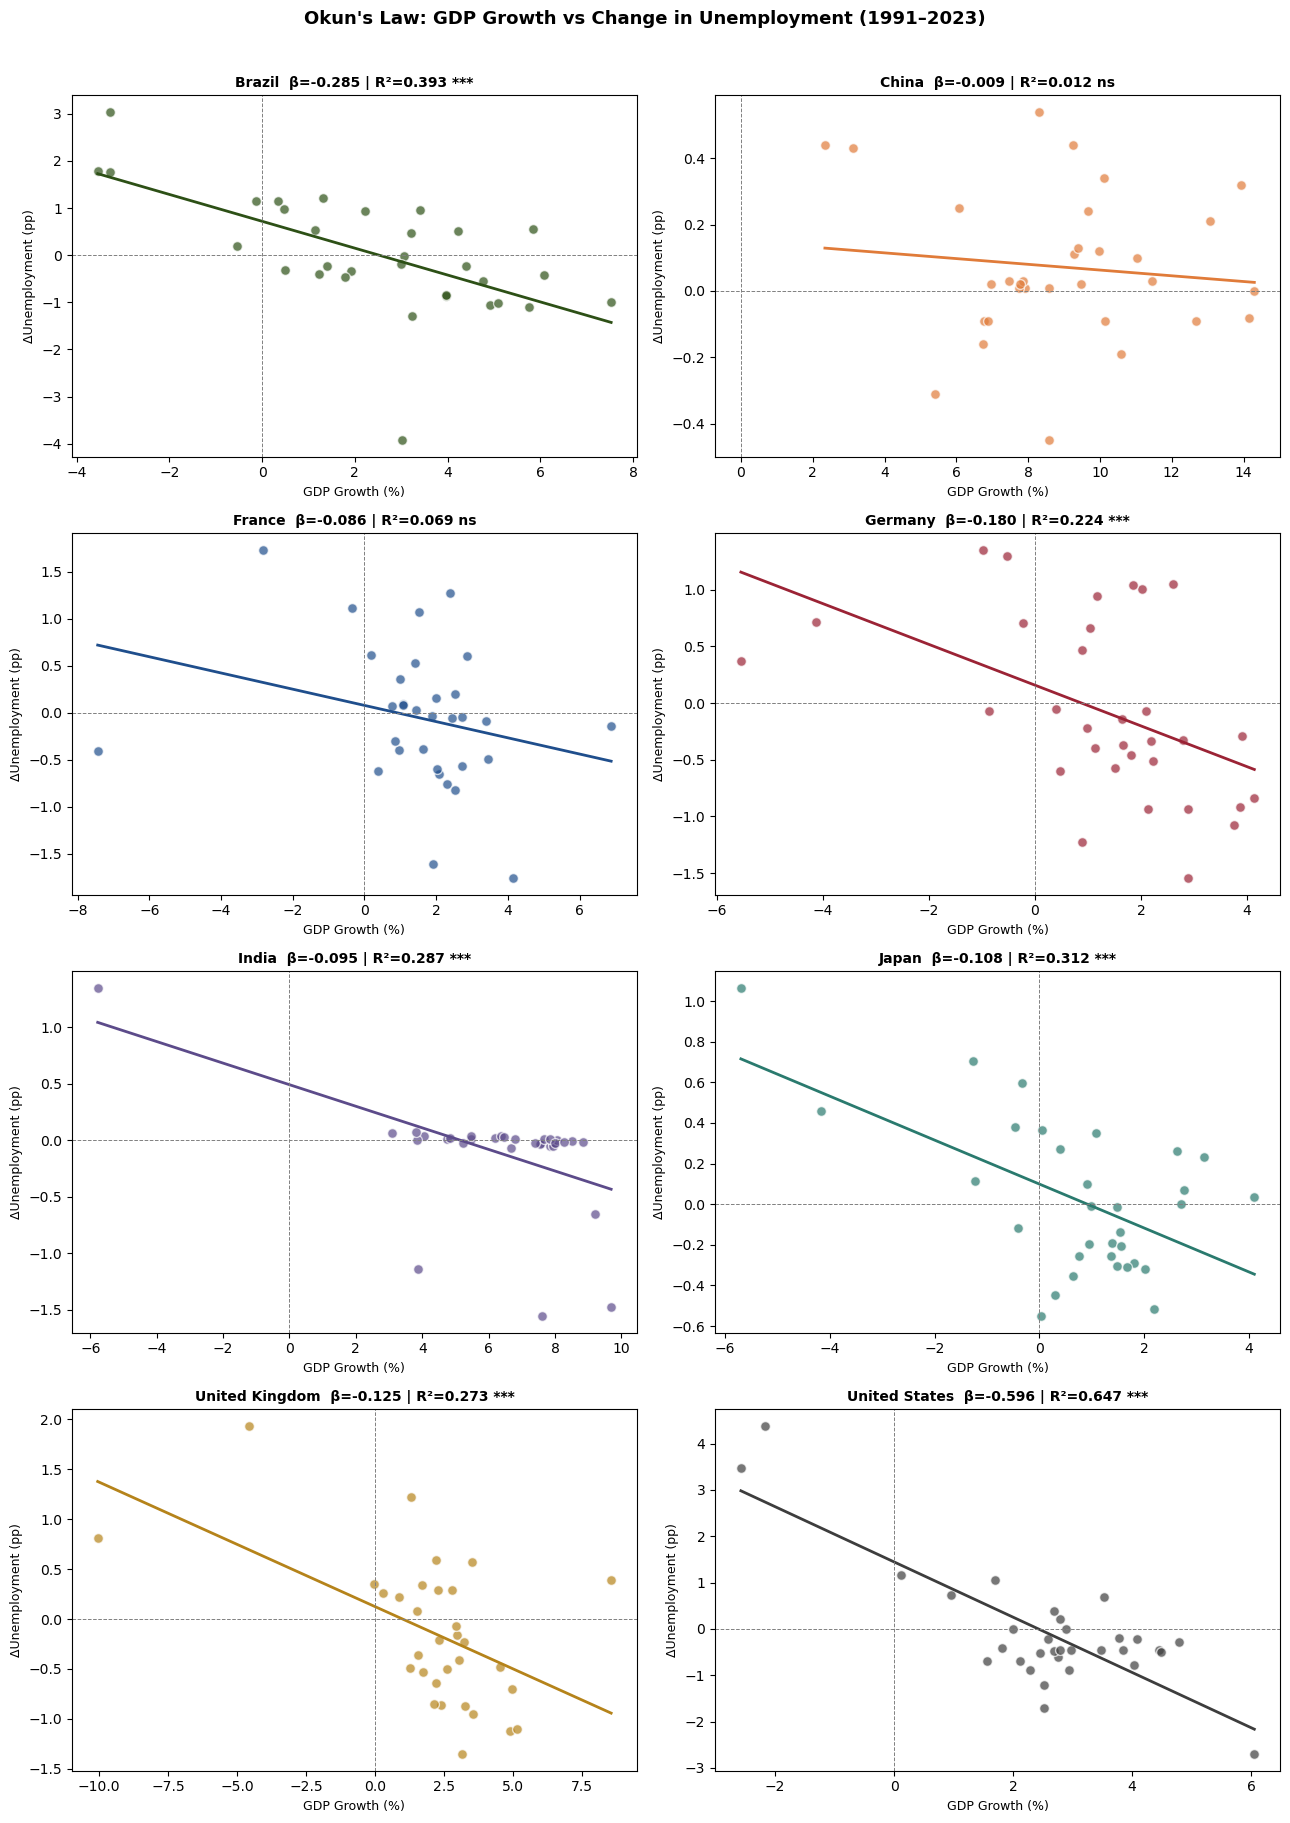

Saved: okun_scatter.png


In [9]:
# Scatter plots with regression lines
fig, axes = plt.subplots(4, 2, figsize=(13, 18))
axes = axes.flatten()

for i, (country, col) in enumerate(zip(COUNTRIES_PLOT, COLORS)):
    cdf = df[df['country'] == country].dropna(subset=['GDP_growth','Delta_U'])
    ax = axes[i]

    slope, intercept, r, p, _ = linregress(cdf['GDP_growth'], cdf['Delta_U'])
    x_line = np.linspace(cdf['GDP_growth'].min(), cdf['GDP_growth'].max(), 100)
    y_line = slope * x_line + intercept

    ax.scatter(cdf['GDP_growth'], cdf['Delta_U'], color=col, alpha=0.7, s=50, edgecolors='white')
    ax.plot(x_line, y_line, color=col, linewidth=2)
    ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.7, linestyle='--')

    sig = '***' if p < 0.01 else ('**' if p < 0.05 else 'ns')
    ax.set_title(f"{country}  β={slope:.3f} | R²={r**2:.3f} {sig}", fontsize=10, fontweight='bold')
    ax.set_xlabel('GDP Growth (%)', fontsize=9)
    ax.set_ylabel('ΔUnemployment (pp)', fontsize=9)

plt.suptitle("Okun's Law: GDP Growth vs Change in Unemployment (1991–2023)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('okun_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: okun_scatter.png')

## 6. Prediction Mode — Scenario Analysis

Using each country's estimated Okun coefficient, we predict the expected change in unemployment for a given hypothetical GDP growth rate.

**Formula:**
$$\hat{\Delta U} = \hat{\alpha} + \hat{\beta} \times g_{\text{scenario}}$$

Three scenarios are tested:
- **Recession:** GDP growth = −2%
- **Slow growth:** GDP growth = +1.5%
- **Strong growth:** GDP growth = +5%

In [10]:
# Build prediction models using full dataset
pred_models = {}
for country in COUNTRIES_PLOT:
    cdf = df[df['country'] == country].dropna(subset=['GDP_growth', 'Delta_U'])
    if len(cdf) < 5:
        continue
    slope, intercept, r, p, _ = linregress(cdf['GDP_growth'], cdf['Delta_U'])
    latest_unem = cdf.sort_values('year')['Unemployment'].iloc[-1]
    pred_models[country] = {
        'slope': slope, 'intercept': intercept,
        'r2': round(r**2, 3), 'p': round(p, 3),
        'latest_unem': latest_unem
    }

print(f'Prediction models built for {len(pred_models)} countries.')

Prediction models built for 8 countries.


In [11]:
# Define scenarios
scenarios = {
    'Recession (GDP = −2%)': -2.0,
    'Slow Growth (GDP = +1.5%)': 1.5,
    'Strong Growth (GDP = +5%)': 5.0
}

# Compute predictions for each scenario
pred_rows = []
for scenario_name, gdp_val in scenarios.items():
    for country, m in pred_models.items():
        delta_u = m['slope'] * gdp_val + m['intercept']
        pred_rows.append({
            'Scenario': scenario_name,
            'Country': country,
            'GDP Growth (%)': gdp_val,
            'Predicted ΔU (pp)': round(delta_u, 3),
            'Latest Unemployment (%)': round(m['latest_unem'], 2),
            'Predicted Unemployment (%)': round(max(m['latest_unem'] + delta_u, 0), 2),
            'Significant': m['p'] < 0.05
        })

pred_df = pd.DataFrame(pred_rows)
print('=== Prediction Results ===')
pred_df.set_index(['Scenario', 'Country'])

=== Prediction Results ===


GDP Growth (%)  Predicted ΔU (pp)  \
Scenario                  Country                                             
Recession (GDP = −2%)     Brazil                    -2.0              1.289   
                          China                     -2.0              0.167   
                          France                    -2.0              0.251   
                          Germany                   -2.0              0.518   
                          India                     -2.0              0.682   
                          Japan                     -2.0              0.316   
                          United Kingdom            -2.0              0.373   
                          United States             -2.0              2.639   
Slow Growth (GDP = +1.5%) Brazil                     1.5              0.291   
                          China                      1.5              0.136   
                          France                     1.5             -0.051   
                          Germany                    1.5             -0.112   
                          India                      1.5              0.348   
                          Japan                      1.5             -0.063   
                          United Kingdom             1.5             -0.063   
                          United States              1.5              0.552   
Strong Growth (GDP = +5%) Brazil                     5.0             -0.706   
                          China                      5.0              0.106   
                          France                     5.0             -0.353   
                          Germany                    5.0             -0.741   
                          India                      5.0              0.014   
                          Japan                      5.0             -0.442   
                          United Kingdom             5.0             -0.500   
                          United States              5.0             -1.535   

                                          Latest Unemployment (%)  \
Scenario                  Country                                   
Recession (GDP = −2%)     Brazil                             7.95   
                          China                              4.67   
                          France                             7.34   
                          Germany                            3.07   
                          India                              4.17   
                          Japan                              2.60   
                          United Kingdom                     4.03   
                          United States                      3.64   
Slow Growth (GDP = +1.5%) Brazil                             7.95   
                          China                              4.67   
                          France                             7.34   
                          Germany                            3.07   
                          India                              4.17   
                          Japan                              2.60   
                          United Kingdom                     4.03   
                          United States                      3.64   
Strong Growth (GDP = +5%) Brazil                             7.95   
                          China                              4.67   
                          France                             7.34   
                          Germany                            3.07   
                          India                              4.17   
                          Japan                              2.60   
                          United Kingdom                     4.03   
                          United States                      3.64   

                                          Predicted Unemployment (%)  \
Scenario                  Country                                      
Recession (GDP = −2%)     Brazil                

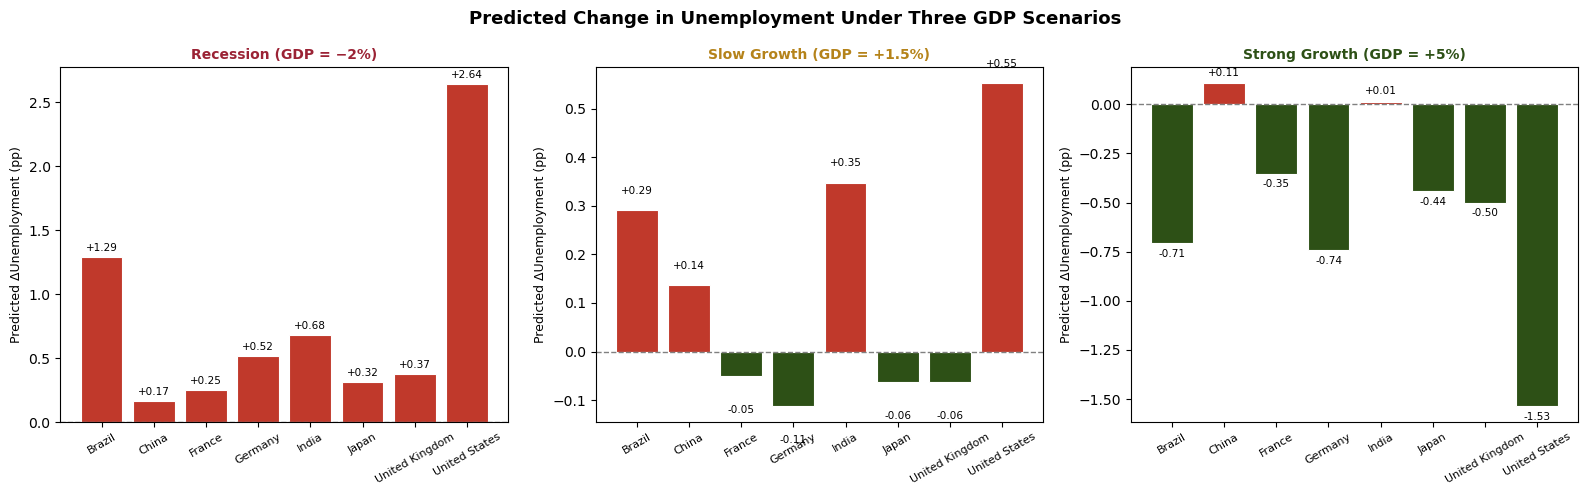

Saved: prediction_scenarios.png


In [12]:
# Visualise predictions across scenarios
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
scenario_colors = ['#9b2335', '#b5831a', '#2d5016']

for ax, (scenario_name, gdp_val), sc_col in zip(axes, scenarios.items(), scenario_colors):
    sdf = pred_df[pred_df['Scenario'] == scenario_name].copy()
    bar_colors = ['#c0392b' if v > 0 else '#2d5016' for v in sdf['Predicted ΔU (pp)']]

    bars = ax.bar(sdf['Country'], sdf['Predicted ΔU (pp)'], color=bar_colors, edgecolor='white', linewidth=0.8)
    ax.axhline(0, color='grey', linewidth=1, linestyle='--')
    ax.set_title(scenario_name, fontsize=10, fontweight='bold', color=sc_col)
    ax.set_ylabel('Predicted ΔUnemployment (pp)', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

    # Label bars
    for bar, val in zip(bars, sdf['Predicted ΔU (pp)']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.03 if val >= 0 else -0.08),
                f'{val:+.2f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Predicted Change in Unemployment Under Three GDP Scenarios',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prediction_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: prediction_scenarios.png')

In [13]:
# Custom single-value prediction (mirrors the Streamlit slider)
gdp_scenario = 3.0   # <-- change this value to test different scenarios

print(f'=== Custom Prediction: GDP Growth = {gdp_scenario:+.1f}% ===\n')
custom_rows = []
for country, m in pred_models.items():
    delta_u = m['slope'] * gdp_scenario + m['intercept']
    new_u = max(m['latest_unem'] + delta_u, 0)
    sig = 'Yes' if m['p'] < 0.05 else 'No'
    custom_rows.append({
        'Country': country,
        'Okun Coeff (β)': round(m['slope'], 3),
        'Predicted ΔU (pp)': round(delta_u, 3),
        'Predicted Unemployment (%)': round(new_u, 2),
        'Statistically Significant': sig
    })

custom_df = pd.DataFrame(custom_rows).set_index('Country')
custom_df

=== Custom Prediction: GDP Growth = +3.0% ===



,Okun Coeff (β),Predicted ΔU (pp),Predicted Unemployment (%),Statistically Significant
Country,,,,
Brazil,-0.285,-0.136,7.81,Yes
China,-0.009,0.123,4.79,No
France,-0.086,-0.180,7.15,No
Germany,-0.180,-0.381,2.69,Yes
India,-0.095,0.205,4.38,Yes
Japan,-0.108,-0.226,2.37,Yes
United Kingdom,-0.125,-0.250,3.77,Yes
United States,-0.596,-0.343,3.30,Yes


## 7. Key Findings and Interpretation

In [14]:
print('=== Summary of Key Findings ===\n')

sig_countries  = results_df[results_df['Significant (p<0.05)']]
insig_countries = results_df[~results_df['Significant (p<0.05)']]

print('Countries where Okun\'s Law is statistically significant (p < 0.05):')
print(sig_countries[['Okun Coefficient (β)', 'R²', 'p-value']].to_string())

print('\nCountries where the relationship is NOT significant:')
print(insig_countries[['Okun Coefficient (β)', 'R²', 'p-value']].to_string())

avg_coeff = results_df['Okun Coefficient (β)'].mean()
print(f'\nAverage Okun coefficient across all countries: {avg_coeff:.3f}')
print('Typical range in the literature: −0.3 to −0.5 for developed economies')

=== Summary of Key Findings ===

Countries where Okun's Law is statistically significant (p < 0.05):
                Okun Coefficient (β)      R²  p-value
Country                                              
Brazil                       -0.2849  0.3931   0.0001
Germany                      -0.1798  0.2242   0.0062
India                        -0.0955  0.2868   0.0016
Japan                        -0.1083  0.3122   0.0009
United Kingdom               -0.1247  0.2734   0.0021
United States                -0.5962  0.6466   0.0000

Countries where the relationship is NOT significant:
         Okun Coefficient (β)      R²  p-value
Country                                       
China                 -0.0086  0.0123   0.5456
France                -0.0863  0.0686   0.1476

Average Okun coefficient across all countries: -0.186
Typical range in the literature: −0.3 to −0.5 for developed economies


## 8. Export Data

In [15]:
df.to_csv('okun_data.csv', index=False)
results_df.to_csv('okun_coefficients.csv')
pred_df.to_csv('okun_predictions.csv', index=False)
print('Exported: okun_data.csv | okun_coefficients.csv | okun_predictions.csv')

Exported: okun_data.csv | okun_coefficients.csv | okun_predictions.csv


## 9. Limitations

1. **Annual data granularity:** Yearly data may obscure cyclical dynamics that quarterly data would capture.
2. **No control variables:** The bivariate model omits labour market institutions, productivity shocks, and structural changes.
3. **Country coverage:** Results cover eight countries; findings should not be over-generalised.
4. **Stationarity:** No formal unit root tests were conducted; GDP growth and unemployment changes are assumed stationary.
5. **Prediction validity:** The prediction mode assumes a stable linear relationship. During structural breaks (e.g. COVID-19, financial crises) the model may underperform.
6. **Data reliability:** World Bank data may incorporate revisions, and coverage varies by country for earlier years.
